In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd


In [90]:
from pysrc.create_models import create_model_config_1_1_1, create_model_config_1_2_1

rep1_post_filepath = '../../cloccs/output/output_yl_02_01_18/posteriors.txt'
rep2_post_filepath = '../../cloccs/output/output_yl_07_13_18/posteriors.txt'

wt1_params, rep1_model = create_model_config_1_1_1(rep1_post_filepath)
wt2_params, rep2_model = create_model_config_1_1_1(rep2_post_filepath)

In [91]:
rep1_model

{'H': [{'h': [-22.3858, -21.3858, 1]}],
 'R': [{'i': [-21.3858, 0, 88]}],
 'CG1': [{'t': [0, 4.60128848, 42]}, {'i': [0, 4.60128848, 42]}],
 'DG1': [{'b': [-19.1625, 4.60128848, 86]}],
 'postG1': [{'t': [4.60128848, 81.0086, 42]},
  {'i': [4.60128848, 81.0086, 42]},
  {'b': [4.60128848, 81.0086, 42]}]}

In [92]:
from pysrc.create_models import get_model_cfg_str

wt1_cfg = get_model_cfg_str(wt1_params, rep1_model)
wt2_cfg = get_model_cfg_str(wt2_params, rep2_model)

with open('../models/yl_cell_cycle/wt1.label', 'w') as f:
    f.write(wt1_cfg)

with open('../models/yl_cell_cycle/wt2.label', 'w') as f:
    f.write(wt2_cfg)
    

In [150]:
wt1_params, rep1_model = create_model_config_1_2_1(rep1_post_filepath)
wt2_params, rep2_model = create_model_config_1_2_1(rep2_post_filepath)

In [151]:
from pysrc.create_models import get_model_cfg_str

wt1_cfg = get_model_cfg_str(wt1_params, rep1_model, Rname="RG1", CG1_intervals="t 0", PG1_intervals="i 1 t 1 b 1")
wt2_cfg = get_model_cfg_str(wt1_params, rep2_model, Rname="RG1", CG1_intervals="t 0", PG1_intervals="i 1 t 1 b 1")

with open('../models/yl_cell_cycle/wt1_rg1.label', 'w') as f:
    f.write(wt1_cfg)

with open('../models/yl_cell_cycle/wt2_rg1.label', 'w') as f:
    f.write(wt2_cfg)
    

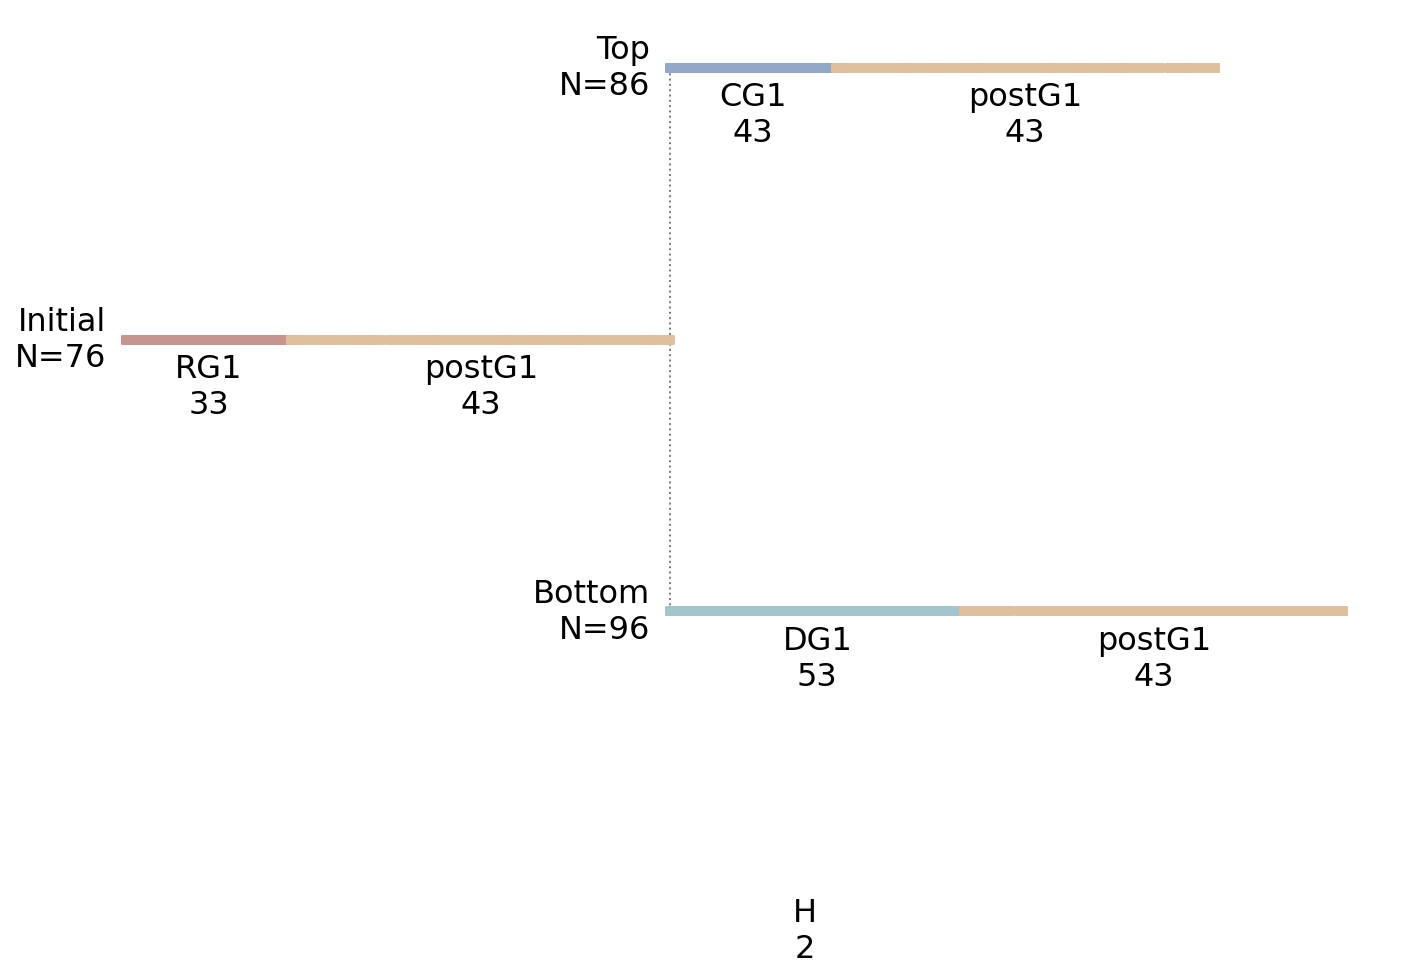

In [152]:
from pysrc.analyze_models import Model

model = Model()
import os

models_directory = '../models/yl_cell_cycle/'
files = os.listdir(models_directory)

#for f in files:
model_path = '../models/yl_cell_cycle/wt1_rg1.label'
model.load_model(model_path)
model.plot_model()
